# Symbolic Knowledge Discovery - WineDataset

This notebook follows the workflow style from:
- `resources/FCA_From_Scratch_SymbolicKD.ipynb`
- `resources/SymbolicKD_Pattern_Mining_+_Clustering.ipynb`

The run is intentionally lightweight to avoid computationally heavy processing:
- full binary-context mining with `caspailleur`
- sampled pattern-space mining with `paspailleur` for subgroup exploration


In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/wine_symbolic_kd_light")
summary = json.loads((OUTPUT_DIR / "summary.json").read_text(encoding="utf-8"))
summary


{'dataset': 'wine',
 'n_objects': 1290,
 'n_binary_features': 71,
 'caspailleur_concepts': 2524,
 'caspailleur_implications': 330,
 'pattern_structure_shape': [10, 45],
 'subgroup_files': {'high_price_quartile': 'subgroups_high_price_quartile.csv'},
 'subgroup_rationale': {'high_price_quartile': 'Price in top quartile (>= 38.49) captures commercially premium wines.'},
 'year_grouping_justification': 'Year-based subgrouping uses broader eras (<=2010 vs >2010) instead of consecutive pairs to reduce sparsity and improve interpretability.'}

## 1) Context and Dataset Overview

We mine a binary context for FCA (caspailleur) and a compact multi-dimensional pattern structure for subgroup-oriented exploration (paspailleur).


In [3]:
context = pd.read_csv(OUTPUT_DIR / "binary_context.csv")
concepts = pd.read_csv(OUTPUT_DIR / "caspailleur_concepts.csv")
implications = pd.read_csv(OUTPUT_DIR / "caspailleur_implications.csv")
feature_importance = pd.read_csv(OUTPUT_DIR / "feature_importance.csv")
interesting_implications = pd.read_csv(OUTPUT_DIR / "interesting_implications.csv")
paspailleur_concepts = pd.read_csv(OUTPUT_DIR / "paspailleur_concepts.csv")

print("Context shape:", context.shape)
print("Caspailleur concepts:", len(concepts))
print("Caspailleur implications:", len(implications))
print("Paspailleur concepts (sampled pattern structure):", len(paspailleur_concepts))


Context shape: (1290, 72)
Caspailleur concepts: 2524
Caspailleur implications: 330
Paspailleur concepts (sampled pattern structure): 244


## 2) Feature Importance (more important vs less important)

Importance combines:
- binary support (frequency)
- stability-weighted concept participation
- implication participation weight


,feature,support_ratio,concept_weight,implication_weight,importance_score
0,harvest_for_vintage_missing,0.998450,4799.030233,6.699535,4806.728217
1,avg_harvest_start_to_2007_missing,0.861240,3131.378295,6.493643,3138.733178
2,Closure_Natural Cork,0.646512,1495.799225,2.503256,1498.948992
3,region_clean_Other,0.561240,1021.462791,4.100155,1026.124186
4,Type_White,0.452713,860.198450,3.226047,863.877209
5,abv_num_low,0.447287,718.839535,2.358760,721.645581
6,Type_Red,0.441085,714.638760,3.587287,718.667132
7,vintage_year_low,0.400775,524.800775,1.225736,526.427287
8,Country_France,0.389147,479.917054,2.282481,482.588682
9,Style_Other,0.382946,417.371318,2.699225,420.453488


,feature,support_ratio,concept_weight,implication_weight,importance_score
56,region_clean_Loire,0.045736,0.594574,0.054884,0.695194
57,Country_USA,0.039535,0.039535,0.047442,0.126512
58,region_clean_Rhône,0.037984,0.000000,0.045581,0.083566
59,Closure_Synthetic Cork,0.018605,0.000000,0.000000,0.018605
60,Closure_Unknown,0.008527,0.000000,0.000000,0.008527
61,abv_num_missing,0.006977,0.000000,0.000000,0.006977
62,avg_harvest_start_to_2007_mid,0.006202,0.000000,0.000000,0.006202
63,Closure_Vinolok,0.005426,0.000000,0.000000,0.005426
64,Type_Unknown,0.003876,0.000000,0.000000,0.003876
65,Type_Tawny,0.003101,0.000000,0.000000,0.003101


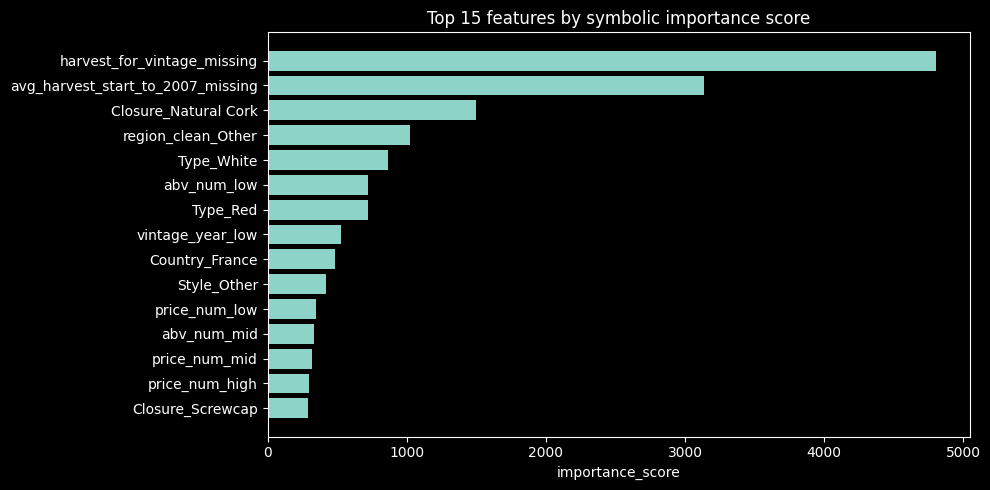

In [4]:
top_features = feature_importance.head(15).copy()
low_features = feature_importance.tail(15).copy()

display(top_features)
display(low_features)

plt.figure(figsize=(10, 5))
plt.barh(top_features["feature"][::-1], top_features["importance_score"][::-1])
plt.title("Top 15 features by symbolic importance score")
plt.xlabel("importance_score")
plt.tight_layout()
plt.show()


## 3) Concepts (including cool/stable concepts)

`caspailleur` returns concept intents/extents with support and delta stability.
We inspect high-support and high-stability concepts.


In [5]:
stable_concepts = concepts.sort_values(["delta_stability", "support"], ascending=[False, False]).head(20)
support_concepts = concepts.sort_values("support", ascending=False).head(20)

display(stable_concepts)
display(support_concepts)


,extent,intent,support,delta_stability
0,"{'wine_0554', 'wine_0768', 'wine_0673', 'wine_...","{'avg_harvest_start_to_2007_missing', 'harvest...",1111,395
1,"{'wine_0554', 'wine_0768', 'wine_0107', 'wine_...","{'avg_harvest_start_to_2007_missing', 'harvest...",716,284
2,"{'wine_0554', 'wine_0768', 'wine_1104', 'wine_...","{'avg_harvest_start_to_2007_missing', 'Closure...",673,241
3,"{'wine_0276', 'wine_0182', 'wine_0808', 'wine_...",{'harvest_for_vintage_missing'},1288,177
4,"{'wine_0768', 'wine_0107', 'wine_0276', 'wine_...","{'Type_White', 'avg_harvest_start_to_2007_miss...",492,172
5,"{'wine_0554', 'wine_0768', 'wine_0276', 'wine_...","{'avg_harvest_start_to_2007_missing', 'Closure...",432,171
6,"{'wine_0768', 'wine_0107', 'wine_0276', 'wine_...","{'avg_harvest_start_to_2007_missing', 'harvest...",490,170
7,"{'wine_0322', 'wine_0554', 'wine_0768', 'wine_...","{'Closure_Natural Cork', 'harvest_for_vintage_...",832,159
8,"{'wine_0322', 'wine_1104', 'wine_0914', 'wine_...","{'Country_France', 'Closure_Natural Cork', 'ha...",416,159
9,"{'wine_0768', 'wine_0107', 'wine_0276', 'wine_...","{'Type_White', 'avg_harvest_start_to_2007_miss...",320,154


,extent,intent,support,delta_stability
1831,"{'wine_0276', 'wine_0182', 'wine_0808', 'wine_...",set(),1290,2
3,"{'wine_0276', 'wine_0182', 'wine_0808', 'wine_...",{'harvest_for_vintage_missing'},1288,177
0,"{'wine_0554', 'wine_0768', 'wine_0673', 'wine_...","{'avg_harvest_start_to_2007_missing', 'harvest...",1111,395
1833,"{'wine_0322', 'wine_0554', 'wine_0768', 'wine_...",{'Closure_Natural Cork'},834,2
7,"{'wine_0322', 'wine_0554', 'wine_0768', 'wine_...","{'Closure_Natural Cork', 'harvest_for_vintage_...",832,159
1212,"{'wine_0554', 'wine_0768', 'wine_0107', 'wine_...","{'harvest_for_vintage_missing', 'region_clean_...",724,8
1,"{'wine_0554', 'wine_0768', 'wine_0107', 'wine_...","{'avg_harvest_start_to_2007_missing', 'harvest...",716,284
2,"{'wine_0554', 'wine_0768', 'wine_1104', 'wine_...","{'avg_harvest_start_to_2007_missing', 'Closure...",673,241
2057,"{'wine_0768', 'wine_0107', 'wine_0276', 'wine_...",{'Type_White'},584,1
31,"{'wine_0768', 'wine_0107', 'wine_0276', 'wine_...","{'Type_White', 'harvest_for_vintage_missing'}",583,91


## 4) Implications (highlight interesting ones)

The table below shows a compact ranked set of implications to discuss (3-5 most interesting).


,premise,conclusion,support,delta_stability,premise_len,conclusion_len,interesting_score
0,{'avg_harvest_start_to_2007_missing'},{'harvest_for_vintage_missing'},1111,395,1,1,1499.85
1,{'region_clean_Other'},{'harvest_for_vintage_missing'},724,8,1,1,977.40
2,{'price_num_low'},{'harvest_for_vintage_missing'},450,19,1,1,607.50
3,"{'Type_White', 'abv_num_low'}",{'harvest_for_vintage_missing'},374,54,2,1,579.70
4,{'Closure_Screwcap'},{'harvest_for_vintage_missing'},414,13,1,1,558.90


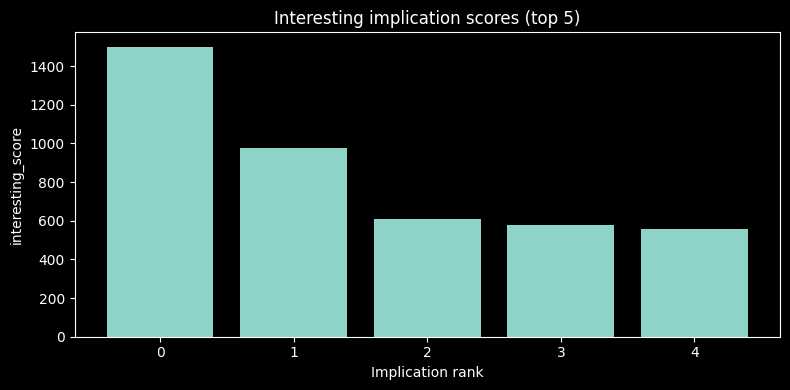

In [6]:
display(interesting_implications.head(5))

if len(interesting_implications) > 0:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(interesting_implications.head(5))), interesting_implications.head(5)["interesting_score"])
    plt.title("Interesting implication scores (top 5)")
    plt.xlabel("Implication rank")
    plt.ylabel("interesting_score")
    plt.tight_layout()
    plt.show()


## 5) Subgroups (binary targets + rationale)

Subgroups are mined as patterns that are highly precise for a **binary target**.

Detected subgroup files: `subgroups_high_price_quartile.csv`.

Rationale used in this run:
- `high_price_quartile`: Price in top quartile (>= 38.49) captures commercially premium wines.

Temporal-grouping policy:
- Prefer broad eras (e.g. <=2010 vs >2010) rather than tiny year-pairs (2001-2002, 2002-2003, ...)
- Reason: broader bins reduce sparsity and improve subgroup interpretability/stability


In [7]:
for csv_file in sorted(OUTPUT_DIR.glob("subgroups_*.csv")):
    print("\n===", csv_file.name, "===")
    df = pd.read_csv(csv_file)
    display(df.head(15))



=== subgroups_high_price_quartile.csv ===


,description,quality,tp,fp,support
0,{'Price': >= 4.99},0.3,3,7,10
1,{'Vintage': >= 1999.0},0.3,3,7,10
2,{'ABV': <= 40.0},0.3,3,7,10
3,{'ABV': >= 0.5},0.3,3,7,10
4,{'Price': <= 430.0},0.3,3,7,10
5,{'Vintage': <= 2023.0},0.3,3,7,10
6,{'Vintage': >= 2019.0},0.3,3,7,10
7,{'ABV': <= 14.5},0.3,3,7,10


## 6) Paspailleur Pattern Concepts (sampled run)

This section mirrors the pattern-mining spirit from the resource notebook but under lightweight constraints.


In [8]:
display(paspailleur_concepts.head(20))


,intent,support,delta_stability
0,"{'ABV': [0.5, 14.5], 'Country': NOT({'Spain', ...",10,NaN
1,"{'ABV': [0.5, 14.5], 'Country': {'Italy', 'Aus...",9,NaN
2,"{'ABV': [0.5, 14.5], 'Country': NOT({'Spain', ...",9,NaN
3,"{'ABV': [0.5, 14.5], 'Country': {'New Zealand'...",9,NaN
4,"{'ABV': [0.5, 14.5], 'Country': {'New Zealand'...",9,NaN
5,"{'ABV': [12.5, 14.5], 'Country': NOT({'Spain',...",9,NaN
6,"{'ABV': [0.5, 14.5], 'Country': NOT({'Spain', ...",8,NaN
7,"{'ABV': [0.5, 14.5], 'Country': {'Italy', 'Aus...",8,NaN
8,"{'ABV': [0.5, 14.5], 'Country': {'New Zealand'...",8,NaN
9,"{'ABV': [0.5, 14.5], 'Country': {'Italy', 'Aus...",8,NaN


## 7) Practical Interpretation Notes

- Use top symbolic features as candidate explanatory variables for recommendation/ranking models.
- Validate highlighted implications with domain experts (oenologists/sommeliers).
- Subgroups should be re-mined on larger compute budgets if exhaustive subgroup quality optimization is required.
